In [1]:
import numpy as np
import matplotlib.pyplot as plt
import simulation_cpu as sim
import scipy.special as scp
import analyze_tool as an


פרמטרים של החומר במאמר:
The film structure that we study is sapphire substrate/FM(10)/capping(x), where FM is Co, Fe or Ni with thickness of 10 nm, and capping(x) is Au, MgO or Pt with thickness of x nm.

מדידת

דברים שמצאנו במאמר:

In [2]:
# magnets matirals proprety

# cobalt
Co_er = 1
Co_sigma = 1.7e7 #https://periodictable.com/Elements/027/data.html
Co_er_complex= -16 + 23.3j 

# Iron
Fe_er = 1
Fe_sigma = 1e7

# nical
Ni_er = 1
Ni_sigma = 1.4e7 #https://periodictable.com/Elements/027/data.html 

alpae_renge = (0.025 ,0.0025) #genral range
gilbert_damping_time = 600e-12 #[sec] artical - concting to alpha in {I dont remmber how}
precession_frequency = 8.5e9 #[Hz] artical

# aditinal matirals proprety
Pt_er = 1
Pt_sigma = 7e6 # [1/oham*m]

Au_er = 1
Au_sigma = 1e6 # (spintronics lab)

condac = {"Co": Co_sigma, "Fe": Fe_sigma, "Ni": Ni_sigma}
alpha = {"Co_Au" : 0.02, "Co_Pt" : 0.025 , "Fe_Au": 0.02, "Fe_Pt" : 0.025, "Ni_Au": 0.05, "Ni_Pt" : 0.06}

key_name = [
            "H times picture",
            "E times picture",
            "ms time picture",
            "time picture",
            "H in locations",
            "E in locations",
            "ms in locations",
            "locations",
            "time intervals",
            "matitral location", "e_r" ,"conductivity", "gilbert damping factor","initial magnetization",
            "max magnetic field" ,"polarization phase","pulse width (FWHM)",
            "systen status", "dt", "safety_start"                
            ]

פולס ברוחב מלא

In [ ]:

# pulse proprty (in the article)
mean_wave_lenght= 784e-9 # [m]
# B_opt =  [0.02, 0.2 ] # [T]
# FWHM = 1.1e-12 #[sec]
FWHM = 1.1e-12 #[sec]
B_opt =2.4e5 #[A/m ] = 0.3[T]

w= 2*np.pi/(mean_wave_lenght/sim.c)


#path = "C:\maxwell-LLG\ws\simulation_result\Full_Width_Pulse\\"
path = "C:\asif_shalom\full_pulse\\"




# besic stuff
time_cycal= mean_wave_lenght/sim.c
dz = 2e-9/8
dt = dz/(2*sim.c)

# matiral length according to arcticle
magntic_steps = 10e-9//dz
conductive_steps = 2e-9//dz

# pulse properties
sefe_start = 3
sigma_pulse = ((0.5/np.log(2))** 0.5) * FWHM # עם זה הרצנו את הכל
# sigma_pulse = 0.5* (np.log(2)**-0.5) * FWHM # זה הגרסא הנכונה לפי הנוסחא של ולפי זה בחרנו זמנים FWHM
peak_enter_time= sefe_start * sigma_pulse
fie = np.pi/2

#material properties
magntic_name = ["Co", "Fe", "Ni"]
conductive_name = ["Au", "Pt"]

magntic_eps = [Co_er, Fe_er, Ni_er ]
conductive_eps = [  Au_er, Pt_er]

magntic_sigma = [Co_sigma, Fe_sigma, Ni_sigma ]
conductive_sigma = [ Au_sigma, Pt_sigma]

ms0 = 3e5*np.array([1, 0, 0 , 0 ,0, -0.0001]).reshape((2,3))

#simulation building blocks
z1 = 8
# z1 = 20
z_end = int(z1+ magntic_steps + conductive_steps)
z_indexes = [z1, int(z1+ magntic_steps), z_end ]


save_loc = np.array([4]+ z_indexes)
# save_loc[0] = 4
save_time= []


void_steps = 2*z1

exit_steps = int(time_cycal/ dt)


# we run in sorter time but this what we need:
simulation_time = int(3*(peak_enter_time//dt + void_steps +4* (magntic_steps + conductive_steps)) + exit_steps)
save_time= [int(0.7*simulation_time)] #it it not look good we shod run one simloltion max alpha with:
save_time = np.linspace(simulation_time*0.5,simulation_time*0.8, 20).astype("int")

In [6]:
feild_save_ind = [0, 1,0, -1]

for mag in range(3):
    for cond in range(2):
        for close_sistem in [False, True]:

            file_name = path + magntic_name[mag] +"_" + conductive_name[cond] 
            
            if close_sistem:
                file_name += "_close.npy"
            else:
                file_name += "_open.npy"

            epsr_list = [magntic_eps[mag], conductive_eps[cond]]
            sigma_list = [magntic_sigma[mag], conductive_sigma[cond]]


            data = sim.simulation(z_indexes, epsr_list , sigma_list, alpha[magntic_name[mag] +"_" + conductive_name[cond]] , ms0,
                    B_opt, fie , FWHM,
                    save_loc, save_time, close_sistem,
                    dt, simulation_time, lamda=mean_wave_lenght, safety_start= sefe_start, time_interval= 7 )

            z2_in_ms = data["matitral location"][1]-data["matitral location"][0]+1
            feild_save_ind[3] = z2_in_ms+ 1
            data["H in locations"] = data["H in locations"][:,feild_save_ind,:]
            data["E in locations"] = data["E in locations"][:,feild_save_ind,:]
            np.save(file_name, data)






simulation pross: 100%|██████████| 14266495/14266495 [1:51:22<00:00, 2134.79it/s]


העברות החזרות

In [ ]:

# pulse proprty (in the article)
mean_wave_lenght= 784e-9 # [m]
# B_opt =  [0.02, 0.2 ] # [T]
# FWHM = 1.1e-12 #[sec]
FWHM = 0.22e-12 #[sec]
B_opt =2.4e5 #[A/m ] = 0.3[T]

w= 2*np.pi/(mean_wave_lenght/sim.c)

# path = "C:\maxwell-LLG\ws\final_result\Return_Transmision_Included\\"
#path = "C:\maxwell-LLG\ws\simulation_result\Return_Tranmision_Incloud\\"

path = "C:\asif_shalom\return_transmission\\"



# besic stuff
lamda = 8e-7 
time_cycal= mean_wave_lenght/sim.c
dz = 2e-9/2
dt = dz/(2*sim.c)

# matiral length according to arcticle
magntic_steps = 10e-9//dz
conductive_steps = 2e-9//dz

# pulse properties
sefe_start = 3
sigma_pulse = ((0.5/np.log(2))** 0.5) * FWHM # עם זה הרצנו את הכל
# sigma_pulse = 0.5* (np.log(2)**-0.5) * FWHM # זה הגרסא הנכונה לפי הנוסחא של FWHM
peak_enter_time= sefe_start * sigma_pulse
fie = np.pi/2

#material properties
magntic_name = ["Co", "Fe", "Ni"]
conductive_name = ["Au", "Pt"]

magntic_eps = [Co_er, Fe_er, Ni_er ]
conductive_eps = [  Au_er, Pt_er]

magntic_sigma = [Co_sigma, Fe_sigma, Ni_sigma ]
conductive_sigma = [ Au_sigma, Pt_sigma]

ms0 = 3e5*np.array([1, 0, 0 , 0 ,0, -0.00001]).reshape((2,3))

#simulation building blocks
z1 = int(2.15*sigma_pulse/dt)
# z1 = 20
z_end = int(z1+ magntic_steps + conductive_steps)
z_indexes = [z1,  int(z1+ magntic_steps), z_end ]


save_loc = np.array([4]+ z_indexes + [0, z_end+1] )
save_loc[3:5] = save_loc[2:4]
save_loc[2] = int(z1+ magntic_steps- 1)
save_time= []


void_steps = 2*z1

exit_steps = int(time_cycal/ dt)



simulation_time = int(2.5*(peak_enter_time//dt + void_steps +4* (magntic_steps + conductive_steps)) + exit_steps)


In [4]:
i = 0
for mag in range(3):
    for cond in range(2):
        for close_sistem in [False, True]:
            i +=1 
            if i < 9:
                continue
            
            file_name = path + magntic_name[mag] +"_" + conductive_name[cond]
            if close_sistem:
                file_name += "_close.npy"
            else:
                file_name+= "_open.npy"
            epsr_list = [magntic_eps[mag], conductive_eps[cond]]
            sigma_list = [magntic_sigma[mag], conductive_sigma[cond]]
            

            data = sim.simulation(z_indexes, epsr_list , sigma_list, alpha[magntic_name[mag] +"_" + conductive_name[cond]] , ms0,
                    B_opt, fie , FWHM,
                    save_loc, save_time, close_sistem,
                    dt, simulation_time, lamda=mean_wave_lenght, safety_start= sefe_start, time_interval= 6 )
            np.save(file_name, data)





simulation pross:   0%|          | 203/1447442 [00:06<12:23:58, 32.42it/s]


KeyboardInterrupt: 

In [8]:

ms_to_ms_for_all = np.zeros((12, z_indexes[1]- z_indexes[0],3))
fie_for_all = np.zeros((12, z_indexes[1]- z_indexes[0]))
magntic_name = ["Co", "Fe", "Ni"]
conductive_name = ["Au", "Pt"]


i =0
for mag in range(3):
    for cond in range(2):
        for close_sistem in [False, True]:
            print(i)
            file_name = path + magntic_name[mag] +"_" + conductive_name[cond]
            if close_sistem:
                file_name += "_close.npy"
            else:
                file_name+= "_open.npy"
 
            data = np.load(file_name, allow_pickle=True)
            data = data.item()
            ms  = np.real(data["ms in locations"])
            z2_in_ms = data["matitral location"][1]-data["matitral location"][0]

            ms_size = np.mean((ms[:,:z2_in_ms,0]**2+ ms[:,:z2_in_ms,1]**2 + ms[:,:z2_in_ms,2]**2)**0.5,0)

            
            sim_cycle_steps = int(time_cycal/(data["dt"]*data["time intervals"]))
            ms_to_mesher = np.mean(ms[-2*sim_cycle_steps:,:z2_in_ms,:],0) 


            # mz_to_m0_in_every_time_step_every_dz = np.real(ms[-2*sim_cycle_steps:,:z2_in_ms,2])/np.real(ms[0,:z2_in_ms,0])
            # mz_to_m0_in_every_dz = np.mean(ms[-2*sim_cycle_steps:,:z2_in_ms,2],0)/ms_size 
            # my_to_m0_in_every_dz = np.mean(ms[-2*sim_cycle_steps:,:z2_in_ms,1],0)/ms_size
            ms_to_ms_for_all[i,:,:]= ms_to_mesher


            
            # ms_end_itration= np.mean(np.real(ms[-2*sim_cycle_steps:,:z2_in_ms,:]),0)
            # fie_for_all[i,:] = (180/np.pi) * np.arccos(mz_to_m0_in_every_dz/ms_size)

            i += 1

data = {"mz": ms_to_ms_for_all[:,:,2], "my" : ms_to_ms_for_all[:,:,1], "mx": ms_to_ms_for_all[:,:,0]}
file_name = path + "summrize.npy"
np.save(file_name, data)


0
1
2
3
4
5
6
7
8
9
10
11


Text(0, 0.5, 'my/ms')

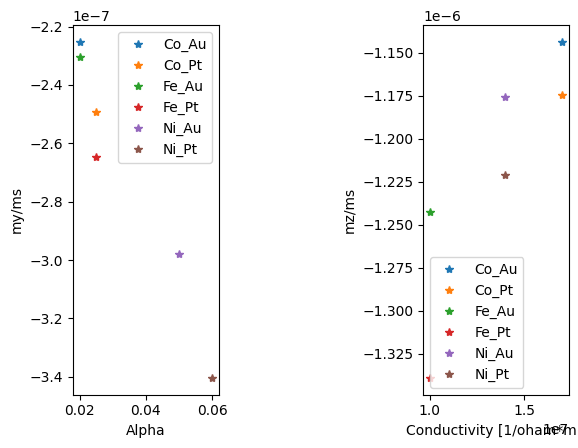

In [74]:
i =0
sim_name_l= []
for mag in range(3):
    for cond in range(2):
        # for close_sistem in [False, True]:
        sim_name = magntic_name[mag] +"_" + conductive_name[cond]
        sim_name_l.append(sim_name)
            # if close_sistem:
            #     sim_name += "_close"
            # else:
            #     sim_name += "_open"
        
        
        plt.subplot(1, 3, 1)
        plt.plot(alpha[sim_name],np.mean(mz_to_ms_for_all[i,:]), "*", label = sim_name)
        # plt.legend()


        plt.subplot(1, 3, 3)
        plt.plot(condac[magntic_name[mag]],np.mean(my_to_ms_for_all[i,:]), "*", label = sim_name)
        i+=2


        # plt.show()
plt.legend()
plt.xlabel("Conductivity [1/oham*m] ")
plt.ylabel("mz/ms")
plt.subplot(1,3,1)
plt.legend()
plt.xlabel("Alpha")
plt.ylabel("my/ms")
# ms_mz_mean = np.mean(mz_to_ms_for_all)

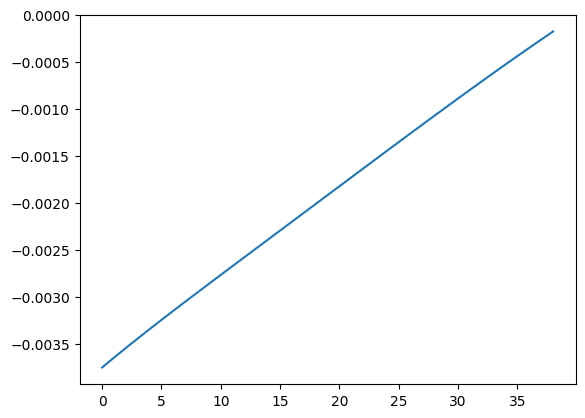

In [21]:
H = data["H in locations"]
# plt.plot(H[:, 0, 0])
ms = data["ms in locations"]
sim_cycle_steps = int(time_cycal/(data["dt"]*data["time intervals"]))
ms_z = ms[-3*sim_cycle_steps:,:z2_in_ms,2]
plt.plot(np.real(ms[-1,:z2_in_ms,2]))

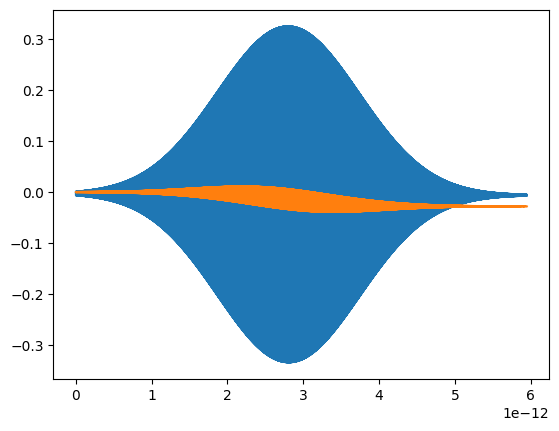

In [46]:
mz_to_ms_for_all = np.zeros((12, z_indexes[1]- z_indexes[0]))

H = data["H in locations"]
ms  = data["ms in locations"]

z2_in_ms = data["matitral location"][1]-data["matitral location"][0]

sim_cycle_steps = int(time_cycal/(data["dt"]*data["time intervals"]))


mz_to_m0_in_every_time_step_every_dz = np.real(ms[-2*sim_cycle_steps:,:z2_in_ms,2])/np.real(ms[0,:z2_in_ms,0])
# mz_to_m0_in_every_time_step = np.mean(mz_to_m0_in_every_time_step_every_dz,1)
mz_to_m0_in_every_dz = np.mean(mz_to_m0_in_every_time_step_every_dz,0) # bigst effact

ms_end_itration= np.mean(ms[-2*sim_cycle_steps:,:z2_in_ms,:],0)
fie_of_mz = (180/np.pi) * np.arctan(((ms_end_itration[:,0]**2 + ms_end_itration[:,1]**2)**0.5)/ms_end_itration[:,2])

t = np.arange(np.size(ms,0))* (data["dt"]*data["time intervals"])

plt.plot(t,np.real(ms[:,0,2]), label = "z")
plt.plot(t,np.real(ms[:,0,1]), label = "y")

# plt.plot(t,np.real(ms[:,0,0]))


# plt.title(sim_name)
# plt.plot(ms[0,:,0])

[     4 170323 170332 170334 170335]
[170323, 170332, 170334]
1.4646177088451196e-12


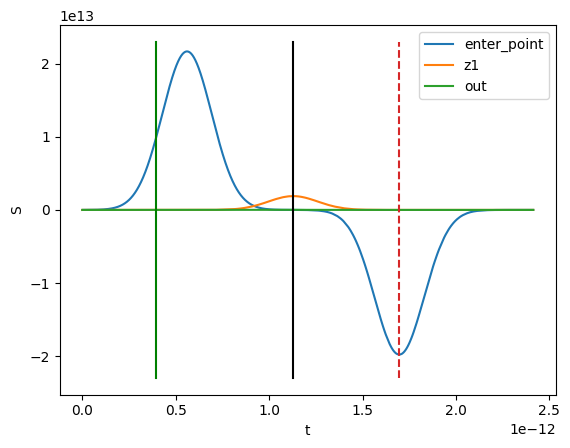

In [60]:



file_name = path + magntic_name[0] +"_" + conductive_name[1]

file_name += "_close.npy"
 
data = np.load(file_name, allow_pickle=True)
data = data.item()
data_dt = data["dt"]* data["time intervals"]
matiral_l = data["matitral location"]
save_indxes = list(data["locations"])


z_enter = 0
z_matirel = save_indxes.index(matiral_l[0])
z_out = save_indxes.index(matiral_l[-1])

z_ind = data["locations"]
E_file= data["E in locations"]


void_steps = 2* data["matitral location"][0]/data["time intervals"]
t1 = int(peak_enter_time/data_dt + void_steps)

t_hm = int((sefe_start* 0.5* (np.log(2)**-0.5) * FWHM)/data_dt)
t2 =int( t1 + void_steps)
t3 = t2 + 2 * magntic_steps// data["time intervals"]
t2_5 =int((t2+ t3)//2)




E = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)
H = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)

E[:,:,0:2] = sim.heta* np. real(E_file)
H[:,:,0:2] = np.real(data["H in locations"])

S = np.cross(np.real(E),np.real(H))

S_in_enter_point = S[:,z_enter,2]
S_in_z1 = S[:,z_matirel,2]
S_in_out = S[:,z_out,2] 
time = np.arange(0, np.size(E_file,0)) *data_dt




S_send_to_void = sum(S_in_enter_point[:t1])*data_dt
S_first_return_to_void = sum(S_in_enter_point[t1:t2_5])*data_dt
S_first_enter_to_matirial = sum(S_in_z1[:t2])*data_dt


transmition = S_first_enter_to_matirial/ S_send_to_void
Return = S_first_return_to_void/ S_send_to_void

print(z_ind)
print(data["matitral location"])
v = np.ones(2)
v_1 = np.array([-1, 1])
plt.plot(time, S_in_enter_point)

plt.plot(time, S_in_z1)
plt.plot(time, S_in_out)
plt.plot(data_dt*t1*v, 2.3e13*v_1, "k")
plt.plot(data_dt*t2*v, 2.3e13*v_1, "--")
plt.plot(data_dt*t_hm*v, 2.3e13*v_1, "g")

# plt.plot([secnd_retuen_time*dt, secnd_retuen_time*dt], [2.7e14, -0.1e14], "k")
plt.legend(["enter_point" , "z1", "out"])
plt.ylabel("S")
plt.xlabel("t")

d ={
    "S_in_enter_point" : S_in_enter_point,
    "S_in_z1" : S[:,2,2],
    "S_in_out" : S[:,-1,2],
    "dt" : data_dt, 
    "t1": float(t1) 
}

file_name = path + "exempel_plot.npy"
np.save(file_name, d)
print(2 * (t1- t_hm)* data_dt)

In [70]:
S_transmission = np.zeros((6,2))
S_return = np.zeros((6,2))
S_pass = np.zeros((6,2))
S_after_material = np.zeros((6,2))
S_bitween_materials = np.zeros((6,2))
i =0
for mag in range(3):
    for cond in range(2):
        for close_sistem in [False, True]:
            file_name = path + magntic_name[mag] +"_" + conductive_name[cond]
            if close_sistem:
                file_name += "_close.npy"
                c =0
            else:
                file_name+= "_open.npy"
                c = 1
            
            data = np.load(file_name, allow_pickle=True)
            data = data.item()
            data_dt = data["dt"]* data["time intervals"]
            matiral_l = data["matitral location"]
            save_indxes = list(data["locations"])


            z_enter = 0
            z_matirel = save_indxes.index(matiral_l[0])
            z_out = save_indxes.index(matiral_l[-1]+1)
            z_end_magnet = save_indxes.index(matiral_l[1])
            # print(f"exist indexes :{save_indxes[:]}")
            # print(f"using numbers : {[z_enter, z_matirel, z_out, z_end_magnet]}")
            
            E_file= data["E in locations"]

            
            void_steps = 2* data["matitral location"][0]/data["time intervals"]
            t1 = int(peak_enter_time/data_dt + void_steps)

            t_hm = int((sefe_start* 0.5* (np.log(2)**-0.5) * FWHM)/data_dt)
            t2 =int( t1 + void_steps)
            t3 = t2 + 2 * magntic_steps// data["time intervals"]
            t2_5 =int((t2+ t3)//2)

            E = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)
            H = np.zeros((np.size(E_file, 0), np.size(E_file,1), 3)) # (time, loction, dimantion)

            E[:,:,0:2] = sim.heta* np. real(E_file)
            H[:,:,0:2] = np.real(data["H in locations"])

            S = np.cross(np.real(E),np.real(H))

            S_in_enter_point = S[:,z_enter,2]
            S_in_z1 = S[:,z_matirel,2]
             
            time = np.arange(0, np.size(E_file,0)) *data_dt




            S_transmission[i,c] = sum(S_in_enter_point[:t1])*data_dt
            S_return[i,c] = sum(S_in_enter_point[t1:])*data_dt
            S_pass[i,c] = sum(S_in_z1)*data_dt
            S_after_material[i,c] = sum(S[:,z_out,2])*data_dt
            S_bitween_materials[i,c] = sum(S[:,z_end_magnet,2])*data_dt
                        
    i += 1


transmition = S_pass/ S_transmission
Return = S_return/ S_transmission
 


exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int64(170335)]
using numbers : [0, 1, 4, 2]
exist indexes :[np.int64(4), np.int64(170323), np.int64(170332), np.int64(170334), np.int6

C:\Users\owner\AppData\Local\Temp\ipykernel_1220\226351659.py:67: RuntimeWarning: invalid value encountered in divide
  transmition = S_pass/ S_transmission
C:\Users\owner\AppData\Local\Temp\ipykernel_1220\226351659.py:68: RuntimeWarning: invalid value encountered in divide
  Return = S_return/ S_transmission
